In [25]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
from electro.circuits import symbolic as sym
from electro.circuits.symbolic import s, t

# Laplace transform of a ramp
---

In [26]:
H_t = sym.ramp(t)
H_s = sym.laplace(H_t)
print("Laplace of ramp(t):", H_s)
sym.print_latex(H_s)

Laplace of ramp(t): s**(-2)


<IPython.core.display.Math object>

# Inverse Laplace of $1/s^2$
---

In [27]:
expr = 1/s**2
h_t = sym.ilaplace(expr)
print("Inverse Laplace of 1/s^2:", h_t)
sym.print_latex(h_t)


Inverse Laplace of 1/s^2: t*Heaviside(t)


<IPython.core.display.Math object>

# Impedance/admittance
---

In [28]:
ZL = sym.Z_inductor(L=2)
YC = sym.Y_capacitor(C=0.5)
print("Inductor impedance:", ZL)
print("Capacitor admittance:", YC)

Inductor impedance: 2*s
Capacitor admittance: 0.5*s


In [29]:
ZT = ZL + 1/YC
sym.print_latex(ZT)

<IPython.core.display.Math object>

# Convert symbolic transfer function to numeric coefficients
---

In [30]:
H_s = (s+1)/(s**2 + 3*s + 2)
num, den = sym.to_numeric_coeffs(H_s)
sym.print_latex(H_s)
print("Numerator coeffs:", num)
print("Denominator coeffs:", den)

# Se observa la simplificación del polo con el cero

<IPython.core.display.Math object>

Numerator coeffs: [1.0]
Denominator coeffs: [1.0, 2.0]


In [31]:
H_tf = sig.TransferFunction(num, den)
H_sym = sym.from_scipy_transferfunc(H_tf)
print("Back to symbolic:", H_sym)
sym.print_latex(H_sym)

Back to symbolic: 1.0/(1.0*s + 2.0)


<IPython.core.display.Math object>

# Frequency response
---

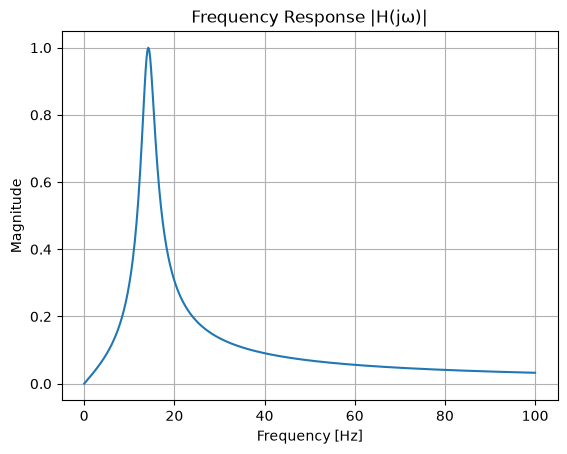

In [32]:
H_s = 20*s/(s**2 + 20*s + 8000)

freqs = np.linspace(0, 100, 500)
resp = sym.to_freq_response(H_s, freqs)

plt.figure()
plt.plot(freqs, np.abs(resp))
plt.title("Frequency Response |H(jω)|")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.grid(True)

# Time response
---

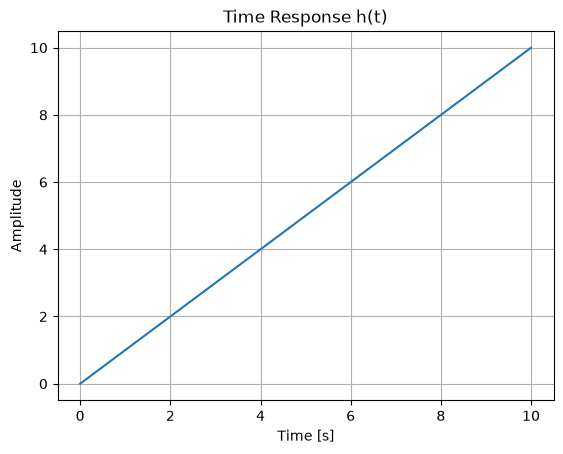

In [33]:
time_axis = np.linspace(0, 10, 500)
resp_t = sym.to_time_response(h_t, time_axis)

plt.figure()
plt.plot(time_axis, resp_t)
plt.title("Time Response h(t)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.show()